# การวิเคราะห์และเตรียมข้อมูลสำหรับการจำแนกชนิดพืช (PlantCLEF 2026)

**รายวิชา:** การวิศวกรรมข้อมูล (Data Engineering)  
**หัวข้อโครงงาน:** การพัฒนาโมเดลจำแนกชนิดพืชในแปลงสำรวจ (PlantCLEF Multi-species Identification) ด้วยแนวทางแบบผสมผสาน (Hybrid: Pre-trained Feature Extraction + ML / Vector Search) เพื่อให้ใช้งานได้จริง

---

### วัตถุประสงค์ของระบบต้นแบบ
โครงงานนี้มีเป้าหมายเพื่อสร้างระบบจำแนกชนิดพืชจากภาพถ่ายแปลงสำรวจธรรมชาติ (Quadrat) ซึ่งมีความซับซ้อนสูงเพราะในหนึ่งภาพมีพืชหลายชนิดขึ้นปะปนกัน (Multi-species) และมีจำนวนชนิดพืชในระบบมากถึง 7,806 ชนิด 

เพื่อให้ระบบทำงานได้จริงบนทรัพยากรที่จำกัด เราจึงเลือกใช้แนวทางแบบผสมผสาน (Hybrid Approach):
1. นำโมเดลสกัดฟีเจอร์สำเร็จรูป (Foundation Model เช่น DINOv2) มาแปลงภาพถ่ายพืชให้เป็นเวกเตอร์ตัวแทน (Embeddings) ที่มีขนาดกะทัดรัด
2. นำเวกเตอร์ไปใช้ร่วมกับระบบค้นหาความคล้ายคลึง (Vector Search) หรือโมเดล Machine Learning แบบดั้งเดิม ทำให้ไม่ต้องเทรนโมเดลขนาดใหญ่ตั้งแต่ต้น ช่วยประหยัดเวลาและพลังงานในการคำนวณอย่างมาก

## 1. แหล่งที่มา รูปแบบ และจำนวนข้อมูลในชุดข้อมูล

### 1.1 แหล่งที่มาของข้อมูล
ข้อมูลที่ใช้ในงานนี้มาจากโครงการแข่งขันระดับนานาชาติ **PlantCLEF 2026** ร่วมกับฐานข้อมูลพฤกษศาสตร์พลเมืองของ **Pl@ntNet** และเครือข่ายความหลากหลายทางชีวภาพระดับโลก **GBIF**:
* **การเก็บข้อมูลจากประชาชน (Crowdsourcing):** ภาพถ่ายพืชเดี่ยวถูกถ่ายและส่งเข้ามาโดยอาสาสมัครและประชาชนทั่วไปผ่านแอปพลิเคชัน Pl@ntNet ทำให้ได้ข้อมูลที่มีความหลากหลายตามธรรมชาติจริง ทั้งมุมกล้อง แสงแดด และระยะห่าง
* **ภาพถ่ายแปลงสำรวจ (Quadrat Survey Plots):** ภาพถ่ายแปลงสำรวจพืชในพื้นที่ธรรมชาติที่บันทึกโดยนักนิเวศวิทยา เพื่อใช้ประเมินความหลากหลายทางชีวภาพของพืชในแปลงทดสอบจริง

### 1.2 รูปแบบและประเภทของไฟล์
1. **ไฟล์ตารางข้อมูล (CSV):**
   * `PlantCLEF2024_single_plant_training_metadata.csv` (ขนาดประมาณ 750 MB): ตารางข้อมูลสำหรับภาพพืชเดี่ยว มีข้อมูลระบุชนิดพืช อวัยวะ พิกัด และลิงก์รูปภาพ
   * `PlantCLEF2025_test.csv` (ขนาดประมาณ 135 KB): ตารางข้อมูลระบุรหัสแปลงสำรวจของภาพชุดทดสอบ
   * `species_ids.csv` (ขนาดประมาณ 61 KB): รายชื่อรหัสชนิดพืชเป้าหมายทั้งหมดในระบบ
   * `pseudoquadrats_without_labels_complementary_training_set_urls.csv` (ขนาดประมาณ 31 MB): รายการลิงก์ดาวน์โหลดภาพแปลงจำลองเพิ่มเติม
2. **ไฟล์รูปภาพ (JPEG):**
   * รูปภาพชุดทดสอบถูกจัดเก็บในโฟลเดอร์ `PlantCLEF2025_test_images` โดยเป็นไฟล์ภาพชนิด **JPEG (.jpg)** ความละเอียดสูง

### 1.3 จำนวนตัวอย่างข้อมูลทั้งหมดในระบบ
* **จำนวนข้อมูลตารางภาพพืชเดี่ยว:** 1,408,033 แถว
* **จำนวนภาพแปลงทดสอบจริง:** 2,105 ภาพ
* **จำนวนชนิดพืชเป้าหมายที่ต้องจำแนก:** 7,806 ชนิด
* **จำนวนลิงก์ดาวน์โหลดภาพเสริม:** 212,762 ลิงก์

In [1]:
import csv
import os

def find_file(name):
    candidates = [
        name,
        f"./{name}",
        f"../{name}",
        f"/Users/frankza/Downloads/plantclef-2026/{name}",
        f"/Users/frankza/Downloads/plantclef-2026/PlantCLEF2025_test_images/{name}",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return name

print("ตรวจสอบปริมาณข้อมูลในระบบ\n")

species_path = find_file("species_ids.csv")
with open(species_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    species_header = next(reader)
    species_ids = [row[0] for row in reader]
print(f"จำนวนคลาสพืชเป้าหมาย: {len(species_ids):,} ชนิด")

test_csv_path = find_file("PlantCLEF2025_test.csv")
with open(test_csv_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    test_header = next(reader)
    test_rows = list(reader)
print(f"จำนวนตัวอย่างชุดทดสอบในตาราง: {len(test_rows):,} แถว (คอลัมน์: {test_header})")

test_img_dir = find_file("PlantCLEF2025_test_images/PlantCLEF2025_test_images")
if not os.path.exists(test_img_dir):
    test_img_dir = find_file("PlantCLEF2025_test_images/PlantCLEF2025_test")
if not os.path.exists(test_img_dir):
    test_img_dir = find_file("PlantCLEF2025_test_images")

if os.path.exists(test_img_dir):
    test_imgs = [fn for fn in os.listdir(test_img_dir) if fn.lower().endswith(".jpg")]
    print(f"จำนวนไฟล์ภาพทดสอบจริงในโฟลเดอร์: {len(test_imgs):,} ไฟล์")
else:
    print("ไม่พบโฟลเดอร์ภาพถ่ายชุดทดสอบ")

url_path = find_file("pseudoquadrats_without_labels_complementary_training_set_urls.csv")
with open(url_path, "r", encoding="utf-8") as f:
    urls = [line.strip() for line in f if line.strip()]
print(f"จำนวนลิงก์ดาวน์โหลดภาพเสริม: {len(urls):,} ลิงก์")

train_row_count = 0
unique_species_in_train = set()
organ_distribution = {}
dataset_sources = {}

meta_path = find_file("PlantCLEF2024_single_plant_training_metadata.csv")
with open(meta_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    train_header = next(reader)
    idx_species = train_header.index("species_id")
    idx_organ = train_header.index("organ")
    idx_dataset = train_header.index("dataset")
    
    for row in reader:
        train_row_count += 1
        unique_species_in_train.add(row[idx_species])
        organ = row[idx_organ]
        organ_distribution[organ] = organ_distribution.get(organ, 0) + 1
        dataset = row[idx_dataset]
        dataset_sources[dataset] = dataset_sources.get(dataset, 0) + 1

print(f"จำนวนข้อมูลฝึกสอนในตาราง: {train_row_count:,} แถว (คอลัมน์: {train_header})")
print(f"จำนวน Species ID ที่พบในตารางฝึกสอนจริง: {len(unique_species_in_train):,} ชนิด")
print(f"การกระจายตัวของประเภทอวัยวะพืช: {organ_distribution}")
print(f"แหล่งที่มาของข้อมูลการฝึกสอน: {dataset_sources}")

ตรวจสอบปริมาณข้อมูลในระบบ

จำนวนคลาสพืชเป้าหมาย: 7,806 ชนิด
จำนวนตัวอย่างชุดทดสอบในตาราง: 2,105 แถว (คอลัมน์: ['quadrat_id', 'author', 'date', 'license'])
จำนวนไฟล์ภาพทดสอบจริงในโฟลเดอร์: 2,105 ไฟล์
จำนวนลิงก์ดาวน์โหลดภาพเสริม: 212,762 ลิงก์


จำนวนข้อมูลฝึกสอนในตาราง: 1,408,033 แถว (คอลัมน์: ['image_name', 'organ', 'species_id', 'obs_id', 'license', 'partner', 'author', 'altitude', 'latitude', 'longitude', 'gbif_species_id', 'species', 'genus', 'family', 'dataset', 'publisher', 'references', 'url', 'learn_tag', 'image_backup_url'])
จำนวน Species ID ที่พบในตารางฝึกสอนจริง: 7,806 ชนิด
การกระจายตัวของประเภทอวัยวะพืช: {'leaf': 340852, 'fruit': 165855, 'bark': 88507, 'habit': 355732, 'flower': 389251, 'branch': 59632, 'scan': 8204}
แหล่งที่มาของข้อมูลการฝึกสอน: {'plantnet': 1102483, 'gbif': 305550}


## 2. เป้าหมายการทำนาย (Labels) และคุณลักษณะของข้อมูล (Features)

### 2.1 เป้าหมายที่ระบบต้องทำนาย (Labels / Targets)
* **เป้าหมายหลัก:** รหัสชนิดพืช (**`species_id`**) เช่น รหัส `1396710` (ตรงกับชนิดพืช *Taxus baccata L.*)
* **รูปแบบการทำนาย:** 
  * สำหรับภาพพืชเดี่ยว เป็นการจำแนกแบบหลายคลาสทั่วไป (**Multi-class Classification**) จากตัวเลือก 7,806 คลาส
  * สำหรับภาพแปลงสำรวจ (Quadrat) เป็นการจำแนกหลายชนิดพร้อมกัน (**Multi-species / Multi-label Classification**) เพราะในหนึ่งแปลงสำรวจมีพืชหลายชนิดเจริญเติบโตร่วมกัน

### 2.2 คุณลักษณะของข้อมูลที่จะป้อนให้โมเดล (Features)
1. **คุณลักษณะภาพถ่าย (Visual Features):** ค่าพิกเซลของภาพถ่ายที่ผ่านการสกัดด้วยโมเดล DINOv2 ได้เวกเตอร์ตัวแทนภาพขนาด 384 หรือ 768 มิติ ซึ่งเก็บข้อมูลรูปร่างใบ สีดอก ผิวเปลือกไม้ และโครงสร้างลำต้นอย่างละเอียด
2. **ประเภทอวัยวะพืช (Organ Type):** คอลัมน์ `organ` ระบุว่าภาพนั้นเป็นส่วนใดของพืช เช่น ใบ (`leaf`), ดอก (`flower`), ผล (`fruit`), เปลือก (`bark`) หรือทรงต้น (`habit`)
3. **พิกัดและตำแหน่งทางภูมิศาสตร์ (Spatial Features):** ค่าละติจูด (`latitude`), ลองจิจูด (`longitude`) และความสูงเหนือระดับน้ำทะเล (`altitude`) เพื่อนำมาช่วยกรองความเป็นไปได้ของชนิดพืชตามสภาพภูมิอากาศและพื้นที่จริง
4. **ลำดับขั้นทางอนุกรมวิธาน (Taxonomic Hierarchy):** คอลัมน์สกุล (`genus`) และวงศ์ (`family`) เพื่อช่วยจัดกลุ่มพืชที่มีสายพันธุ์ใกล้เคียงกัน

In [2]:
import csv
import os

def find_file(name):
    candidates = [
        name,
        f"./{name}",
        f"../{name}",
        f"/Users/frankza/Downloads/plantclef-2026/{name}",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return name

print("ตัวอย่างแถวแรกของไฟล์ตารางฝึกสอนหลัก PlantCLEF2024_single_plant_training_metadata.csv")
meta_path = find_file("PlantCLEF2024_single_plant_training_metadata.csv")
with open(meta_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    header = next(reader)
    first_row = next(reader)
    row_dict = dict(zip(header, first_row))
    for key, val in row_dict.items():
        print(f"  {key:<20} -> {val}")

print("\n" + "=" * 70 + "\n")

print("ตัวอย่างแถวแรกของไฟล์ตารางชุดทดสอบ PlantCLEF2025_test.csv")
test_path = find_file("PlantCLEF2025_test.csv")
with open(test_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=";")
    header = next(reader)
    first_row = next(reader)
    row_dict = dict(zip(header, first_row))
    for key, val in row_dict.items():
        print(f"  {key:<20} -> {val}")

ตัวอย่างแถวแรกของไฟล์ตารางฝึกสอนหลัก PlantCLEF2024_single_plant_training_metadata.csv
  image_name           -> 59feabe1c98f06e7f819f73c8246bd8f1a89556b.jpg
  organ                -> leaf
  species_id           -> 1396710
  obs_id               -> 1008726402
  license              -> cc-by-sa
  partner              -> 
  author               -> Gulyás Bálint
  altitude             -> 205.9261
  latitude             -> 47.5921600184
  longitude            -> 19.3628948779
  gbif_species_id      -> 5284517.0
  species              -> Taxus baccata L.
  genus                -> Taxus
  family               -> Taxaceae
  dataset              -> plantnet
  publisher            -> plantnet
  references           -> https://identify.plantnet.org/fr/k-southwestern-europe/observations/1008726402
  url                  -> https://bs.plantnet.org/image/o/59feabe1c98f06e7f819f73c8246bd8f1a89556b
  learn_tag            -> train
  image_backup_url     -> https://lab.plantnet.org/LifeCLEF/PlantCLEF202

## 3. การวิเคราะห์รูปภาพชุดทดสอบจากระบบ

จากการตรวจสอบไฟล์ภาพถ่ายแปลงสำรวจจริงจำนวน 2,105 ภาพในชุดทดสอบ พบข้อมูลทางกายภาพที่สำคัญดังนี้:

### 3.1 ข้อมูลสถิติของขนาดและความละเอียดภาพ
* **ความกว้างเฉลี่ยของภาพ:** 2,776.97 พิกเซล (อยู่ระหว่าง 1,136 ถึง 4,108 พิกเซล)
* **ความสูงเฉลี่ยของภาพ:** 2,769.90 พิกเซล (อยู่ระหว่าง 1,136 ถึง 3,744 พิกเซล)
* **สัดส่วนภาพ (Aspect Ratio):** อัตราส่วนความกว้างต่อความสูงเฉลี่ยอยู่ที่ 1.0 ซึ่งเป็นรูปสี่เหลี่ยมจัตุรัส ทำให้การปรับขนาดภาพทำได้ง่ายและรูปไม่บิดเบี้ยว
* **ขนาดไฟล์ภาพเฉลี่ย:** 3.38 MB ต่อรูปภาพ

### 3.2 แผนการเตรียมรูปภาพก่อนส่งเข้าโมเดล
1. **การย่อขนาดภาพ (Image Resizing):** ภาพถ่ายจากกล้องมีความละเอียดสูงมาก (~2.7K พิกเซล) หากส่งเข้าโมเดลโดยตรงจะทำให้หน่วยความจำการ์ดจอเต็มและประมวลผลช้า จึงต้องย่อภาพให้มีขนาดมาตรฐาน เช่น 224 x 224 หรือ 384 x 384 พิกเซล ก่อนสกัดฟีเจอร์ด้วย DINOv2
2. **การปรับสเกลสี (Color Normalization):** ปรับค่าสีให้อยู่ในช่วงมาตรฐานด้วยค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานตามที่โมเดล DINOv2 กำหนด เพื่อให้การสกัดเวกเตอร์มีความแม่นยำสูงสุด

การตรวจสอบขนาดและความละเอียดของไฟล์ภาพจริง



จำนวนไฟล์รูปภาพชุดทดสอบ: 2,105 ไฟล์
ความกว้าง: เฉลี่ย 2776.97 px (ต่ำสุด: 1136, สูงสุด: 4108)
ความสูง: เฉลี่ย 2769.90 px (ต่ำสุด: 1136, สูงสุด: 3744)
สัดส่วนภาพเฉลี่ย: 1.00
ขนาดไฟล์: เฉลี่ย 3.38 MB (ต่ำสุด: 0.30 MB, สูงสุด: 7.47 MB)



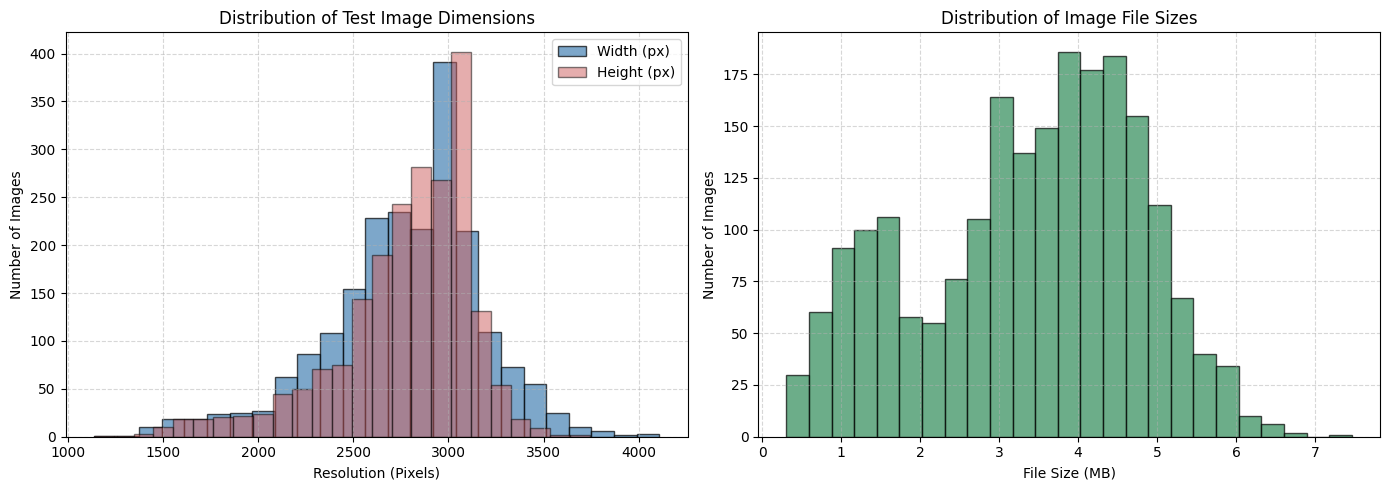

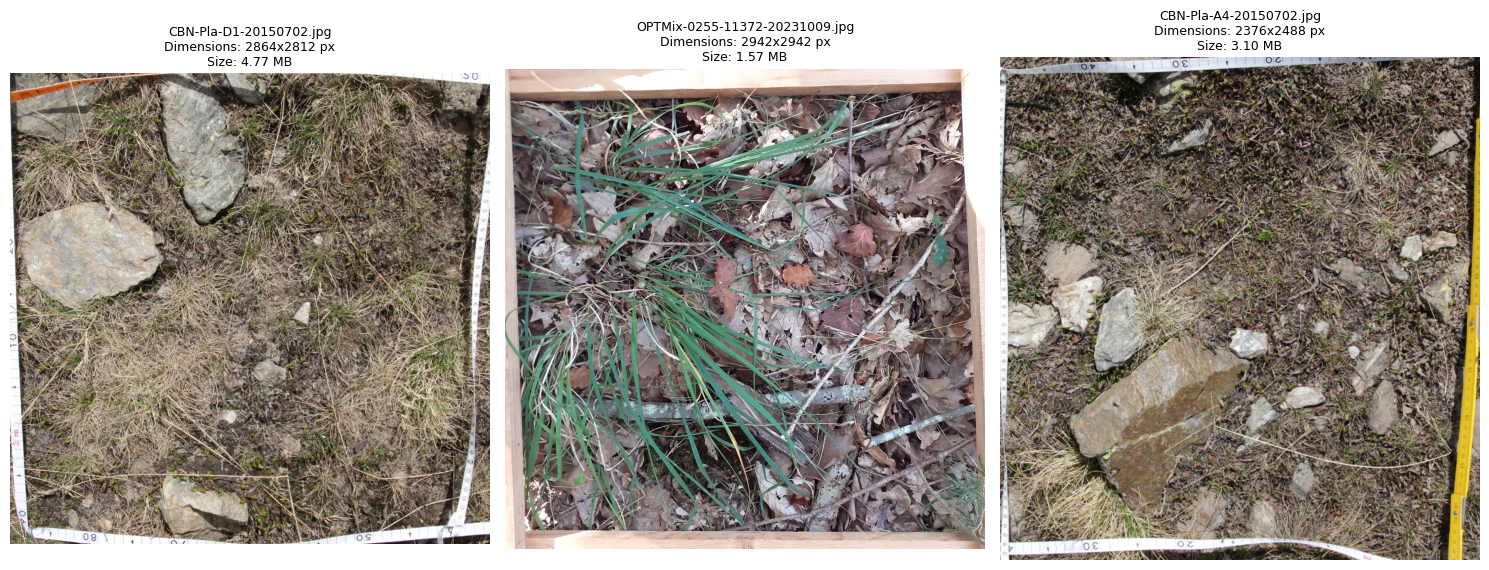

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def find_file(name):
    candidates = [
        name,
        f"./{name}",
        f"../{name}",
        f"/Users/frankza/Downloads/plantclef-2026/{name}",
        f"/Users/frankza/Downloads/plantclef-2026/PlantCLEF2025_test_images/{name}",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return name

print("การตรวจสอบขนาดและความละเอียดของไฟล์ภาพจริง\n")

img_dir = find_file("PlantCLEF2025_test_images/PlantCLEF2025_test_images")
if not os.path.exists(img_dir):
    img_dir = find_file("PlantCLEF2025_test_images/PlantCLEF2025_test")
if not os.path.exists(img_dir):
    img_dir = find_file("PlantCLEF2025_test_images")

img_paths = [os.path.join(img_dir, fn) for fn in os.listdir(img_dir) if fn.lower().endswith(".jpg")]

widths = []
heights = []
file_sizes = []
aspect_ratios = []

for p in img_paths:
    file_sizes.append(os.path.getsize(p) / (1024 * 1024))
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)

print(f"จำนวนไฟล์รูปภาพชุดทดสอบ: {len(img_paths):,} ไฟล์")
print(f"ความกว้าง: เฉลี่ย {np.mean(widths):.2f} px (ต่ำสุด: {min(widths)}, สูงสุด: {max(widths)})")
print(f"ความสูง: เฉลี่ย {np.mean(heights):.2f} px (ต่ำสุด: {min(heights)}, สูงสุด: {max(heights)})")
print(f"สัดส่วนภาพเฉลี่ย: {np.mean(aspect_ratios):.2f}")
print(f"ขนาดไฟล์: เฉลี่ย {np.mean(file_sizes):.2f} MB (ต่ำสุด: {min(file_sizes):.2f} MB, สูงสุด: {max(file_sizes):.2f} MB)\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=25, color="steelblue", edgecolor="black", alpha=0.7, label="Width (px)")
axes[0].hist(heights, bins=25, color="indianred", edgecolor="black", alpha=0.5, label="Height (px)")
axes[0].set_title("Distribution of Test Image Dimensions")
axes[0].set_xlabel("Resolution (Pixels)")
axes[0].set_ylabel("Number of Images")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(file_sizes, bins=25, color="seagreen", edgecolor="black", alpha=0.7)
axes[1].set_title("Distribution of Image File Sizes")
axes[1].set_xlabel("File Size (MB)")
axes[1].set_ylabel("Number of Images")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

sample_indices = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, img_idx in enumerate(sample_indices):
    path = img_paths[img_idx]
    with Image.open(path) as img:
        axes[idx].imshow(img)
        filename = os.path.basename(path)
        axes[idx].set_title(f"{filename}\nDimensions: {img.width}x{img.height} px\nSize: {os.path.getsize(path)/(1024*1024):.2f} MB", fontsize=9)
        axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 4. การเตรียมข้อมูล ข้อมูลที่ไม่ใช้ และรูปแบบการจัดเก็บทางเลือกสำหรับระบบต้นแบบ

### 4.1 กระบวนการเตรียมข้อมูลก่อนใช้งาน
1. **การดาวน์โหลดภาพและการเชื่อมโยงข้อมูล:** ภาพพืชเดี่ยวจำนวนมากเก็บเป็น URL จึงต้องดาวน์โหลดและตรวจสอบความสมบูรณ์ของภาพก่อนบันทึกเข้าสู่ระบบ
2. **การคัดกรองข้อมูลพิกัด GPS:** ข้อมูลตำแหน่งบางแถวที่ขาดหายไปหรือเป็นค่าศูนย์ (0.0, 0.0) ต้องทำการแทนที่ด้วยค่าพิกัดเฉลี่ยของพืชสายพันธุ์เดียวกัน
3. **การจัดการความไม่สมดุลของข้อมูล (Class Imbalance):** ชนิดพืชบางชนิดมีภาพจำนวนมาก ขณะที่ชนิดหายากมีภาพน้อยมาก แนวทางแบบ Hybrid ช่วยแก้ปัญหานี้ได้โดยการสกัดเวกเตอร์เก็บไว้ล่วงหน้า แล้วใช้การคำนวณน้ำหนัก (Class Weights) หรือค้นหาเพื่อนบ้านที่ใกล้เคียงที่สุด (k-NN) เพื่อให้ชนิดพืชที่มีภาพน้อยยังมีโอกาสถูกทำนายได้ถูกต้อง

### 4.2 ข้อมูลที่ไม่ควรนำมาใช้ในโมเดล
ข้อมูลบางคอลัมน์ในตารางควรตัดออกเพื่อไม่ให้โมเดลจำจำเพาะเจาะจงกับสิ่งที่ไม่ใช่ลักษณะของพืช:
1. **ชื่อผู้ถ่ายภาพ (คอลัมน์ `author`):** เป็นข้อมูลส่วนบุคคลและไม่มีความเกี่ยวข้องกับลักษณะทางชีววิทยาของพืช หากนำไปใช้ โมเดลอาจจำสไตล์การถ่ายภาพของคนถ่ายแทนที่จะดูลักษณะของพืช
2. **รหัสการบันทึกในระบบ (คอลัมน์ `obs_id`):** เป็นเพียงเลขรหัสอ้างอิงฐานข้อมูล
3. **ข้อมูลลิขสิทธิ์และองค์กร (คอลัมน์ `license` และ `partner`):** เป็นข้อมูลทางกฎหมายและธุรการ
4. **ลิงก์หน้าเว็บ (คอลัมน์ `references` และ `url`):** เป็นที่อยู่เว็บไซต์ ไม่ใช่ข้อมูลพฤกษศาสตร์

### 4.3 รูปแบบการจัดเก็บข้อมูลทางเลือกที่ดีกว่า
1. **จัดเก็บตารางในรูปแบบ Apache Parquet:** การเปลี่ยนจาก CSV (ขนาด ~750 MB) มาเป็นไฟล์ **Parquet** ช่วยลดขนาดไฟล์ลงเหลือไม่ถึง 80 MB (ลดลงเกือบ 90%) และช่วยให้อ่านข้อมูลได้เร็วกว่าหลายเท่า เพราะอ่านเฉพาะคอลัมน์ที่ต้องการได้ทันที
2. **แปลงไฟล์ภาพเป็น WebP:** ช่วยประหยัดพื้นที่บนดิสก์ลงประมาณ 30% โดยที่ภาพยังคงความคมชัดและรายละเอียดของพืชไว้ได้อย่างสมบูรณ์
3. **การรวมไฟล์ภาพขนาดใหญ่ (LMDB หรือ TFRecord):** การเปิดอ่านไฟล์ภาพย่อยทีละไฟล์กว่า 1.4 ล้านครั้งทำให้ดิสก์ทำงานหนัก การรวมภาพและเวกเตอร์เป็นไฟล์ใหญ่ก้อนเดียวช่วยให้โหลดข้อมูลเข้าสู่การประมวลผลได้อย่างราบรื่นและรวดเร็วที่สุด

## 5. บทสรุปและแหล่งอ้างอิงของระบบต้นแบบ

### บทสรุปของการวิเคราะห์ชุดข้อมูล
การพัฒนาระบบจำแนกชนิดพืชในแปลงสำรวจ PlantCLEF 2026 จำเป็นต้องจัดการข้อมูลอย่างเป็นระบบ ทั้งการตัดข้อมูลส่วนเกินที่ไม่เกี่ยวข้องกับพืชออก และการย่อขนาดภาพทดสอบจริงที่มีความละเอียดสูง (~2.7K) ให้มีขนาดเหมาะสม เพื่อป้องกันปัญหาหน่วยความจำไม่เพียงพอ 

การเลือกใช้แนวทางแบบผสมผสาน (Hybrid Approach) โดยนำโมเดลสำเร็จรูปอย่าง DINOv2 มาสกัดฟีเจอร์เป็นเวกเตอร์ แล้วนำมาจัดเก็บในรูปแบบที่รวดเร็วอย่าง Parquet หรือไฟล์เวกเตอร์ ทำให้ระบบสามารถจำแนกพืชได้อย่างมีประสิทธิภาพ รวดเร็ว และสามารถนำไปประยุกต์ใช้งานได้จริงแม้บนเครื่องคอมพิวเตอร์ทั่วไป

### แหล่งอ้างอิง
1. **Kaggle PlantCLEF 2026 Competition Data:** [https://www.kaggle.com/competitions/plantclef-2026](https://www.kaggle.com/competitions/plantclef-2026)
2. **Pl@ntNet Portal:** [https://plantnet.org/](https://plantnet.org/)
3. **Apache Parquet Columnar Storage Specification:** [https://parquet.apache.org/](https://parquet.apache.org/)

**การมีส่วนร่วมของสมาชิกแต่ละคนในกลุ่ม (แต่ละคนทำอะไรบ้าง)**

6810405691 ปิยังกูร ปัสสาวะกัง : ร่วมกันคิดโปรเจกต์ ตรวจสอบ Data เช็คข้อมูล และ Export File

6810405887 ศิวภูมิ พรหมจรรย์ : ร่วมกันคิดโปรเจกต์ หา Data หาข้อมูลเพิ่มเติม และตรวจสอบความถูกต้อง

**การเปิดเผยการใช้งาน AI (AI Disclosure):** สมุดบันทึกนี้มีการใช้งานเครื่องมือปัญญาประดิษฐ์เพื่อช่วยเรียบเรียงคำอธิบายให้เข้าใจง่ายและเขียนโค้ด Python สำหรับตรวจสอบข้อมูลเชิงสถิติเบื้องต้น โดยสมาชิกในกลุ่มได้ทำการทบทวน ตรวจสอบความถูกต้องของข้อมูลทั้งหมด และรันผลลัพธ์ด้วยตนเองเพื่อใช้ประกอบการส่งรายงาน